# 🔥 Oregon Wildfire Model V3 — Fire-Level Merged Dataset
### WildfireNetV3 · Per-Fire Weather Conditions · Multi-Task PyTorch Model

---

**Dataset:** `oregon_fires_weather_merged_with_prism.csv`  
One row per fire, each enriched with:
- GSOD weather station observations **on the day of the fire** (temperature, wind, dew point, VPD proxy)
- PRISM gridded climate context (prior-winter precip, fire-month precip)
- ODF fire metadata (fuel model, cause, county, location)

**Excluded features:** `PRCP`, `PRCP_30DAY` *(flagged as flawed — not used anywhere in this notebook)*

**Train/Val/Test split:**
- **Train:** 2011–2018 (7,798 fires, 188 large ≥100 ac)
- **Val:** 2019 (1,016 fires, 9 large)
- **Test:** 2020 (978 fires, 37 large — Oregon's worst recorded wildfire year)

> ⚠️ 2021 is excluded from evaluation: the dataset only covers Jan–May 2021 with no fire-season months.


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, json, pickle
from datetime import datetime, timezone
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_absolute_error, r2_score,
                             roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")


PyTorch 2.8.0 | Device: cpu


## 2. Load & Validate Dataset

In [2]:
df_raw = pd.read_csv('oregon_fires_weather_merged_with_prism.csv')
print(f"Rows: {len(df_raw):,}  |  Columns: {len(df_raw.columns)}")
print(f"Years: {sorted(df_raw['fire_year'].unique())}")
print(f"Counties: {df_raw['county'].nunique()}")
print()

# Confirm PRCP and PRCP_30DAY are present but will NOT be used
print("PRCP / PRCP_30DAY present:", 'PRCP' in df_raw.columns, '/', 'PRCP_30DAY' in df_raw.columns)
print("→ These columns are EXCLUDED from all feature sets per data quality requirements.")
print()

# Quick sanity check on target
acres = df_raw['total_acres'].fillna(0).clip(lower=0)
print("total_acres distribution:")
print(acres.describe().round(2))
print(f"\nFires ≥ 100 ac:  {(acres >= 100).sum():,}  ({(acres >= 100).mean():.2%})")
print(f"Fires ≥ 1000 ac: {(acres >= 1000).sum():,}  ({(acres >= 1000).mean():.2%})")


Rows: 10,046  |  Columns: 33
Years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Counties: 35

PRCP / PRCP_30DAY present: True / True
→ These columns are EXCLUDED from all feature sets per data quality requirements.

total_acres distribution:
count     10046.00
mean        286.67
std        5050.17
min           0.00
25%           0.01
50%           0.10
75%           0.50
max      193566.00
Name: total_acres, dtype: float64

Fires ≥ 100 ac:  236  (2.35%)
Fires ≥ 1000 ac: 101  (1.01%)


## 3. Exploratory Data Analysis

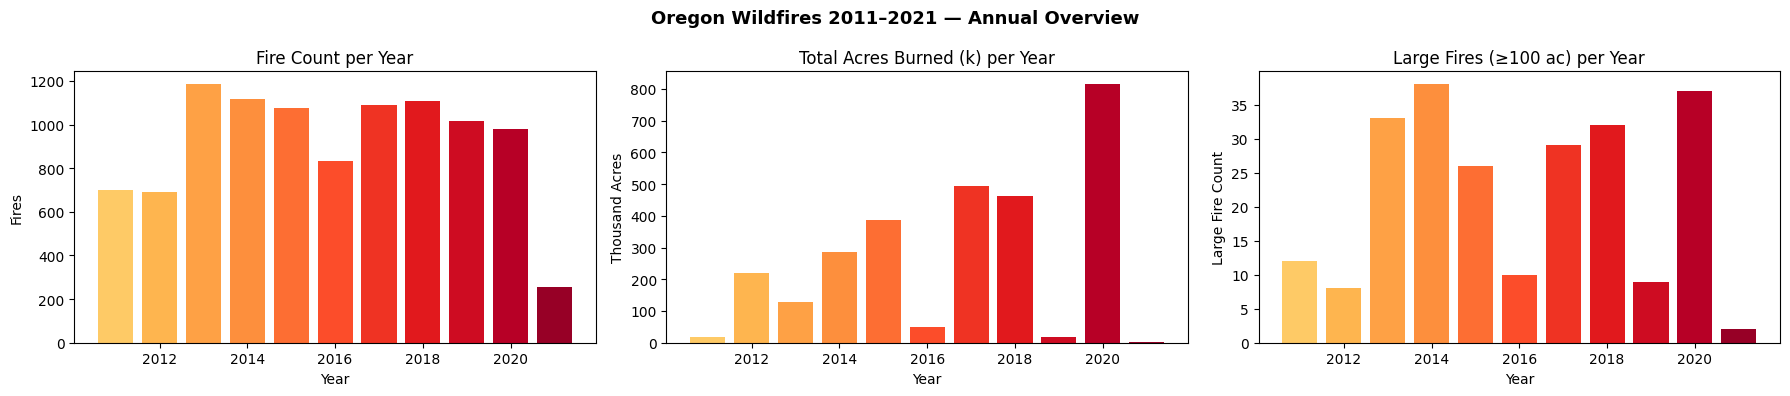

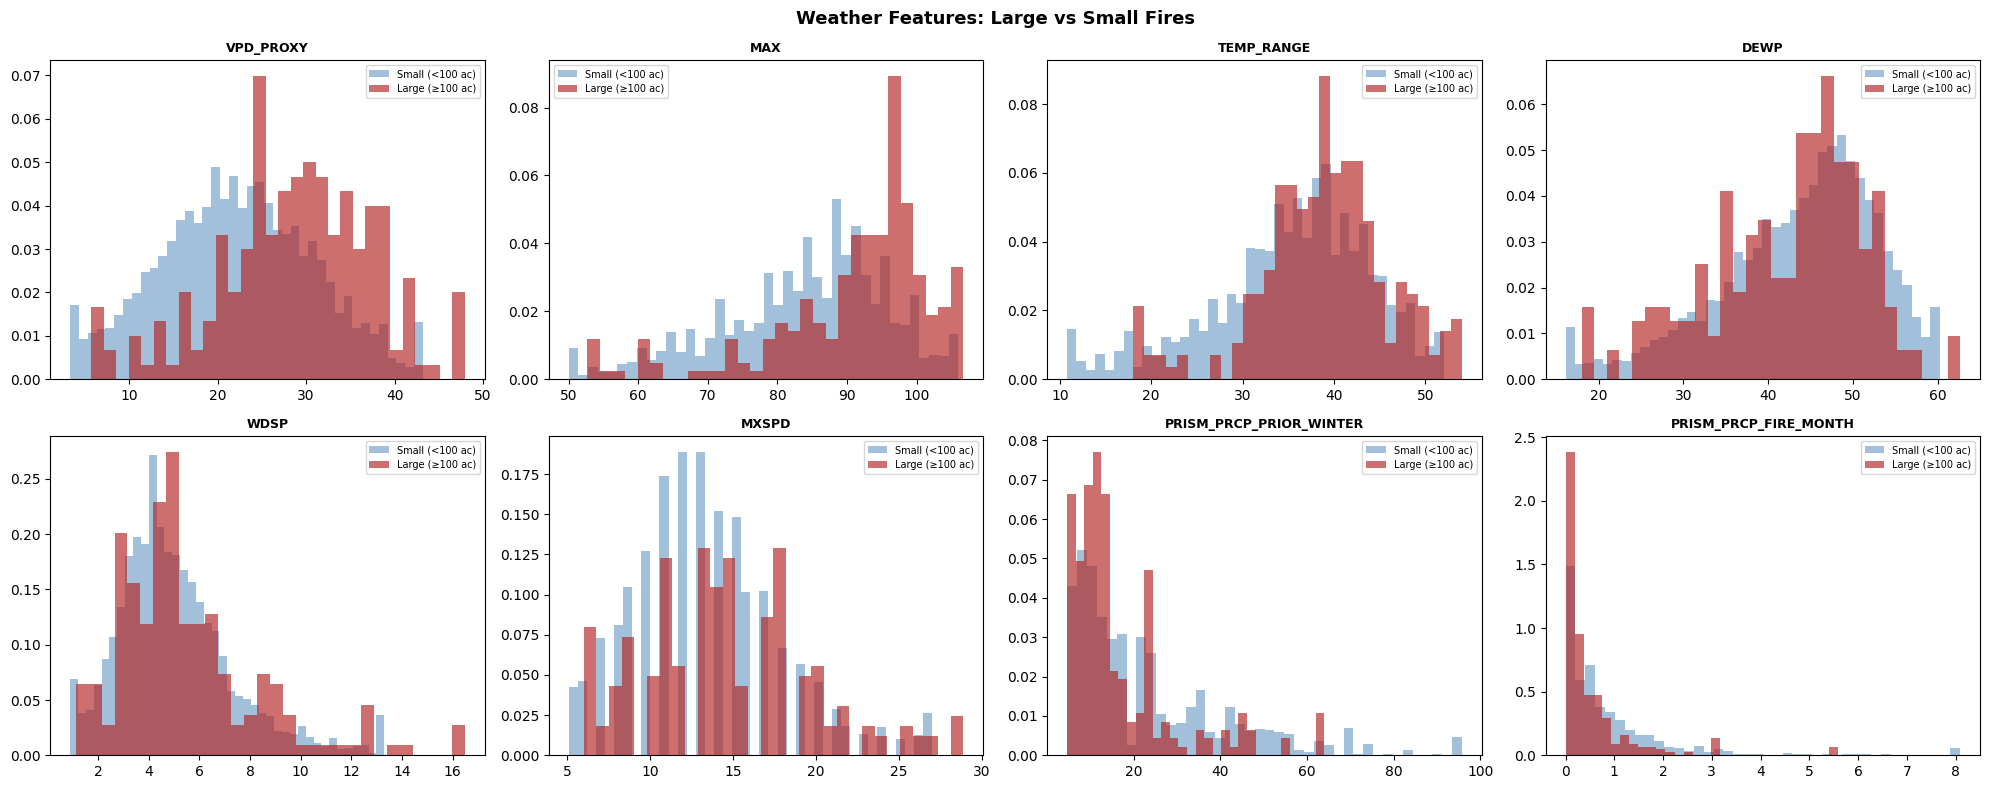

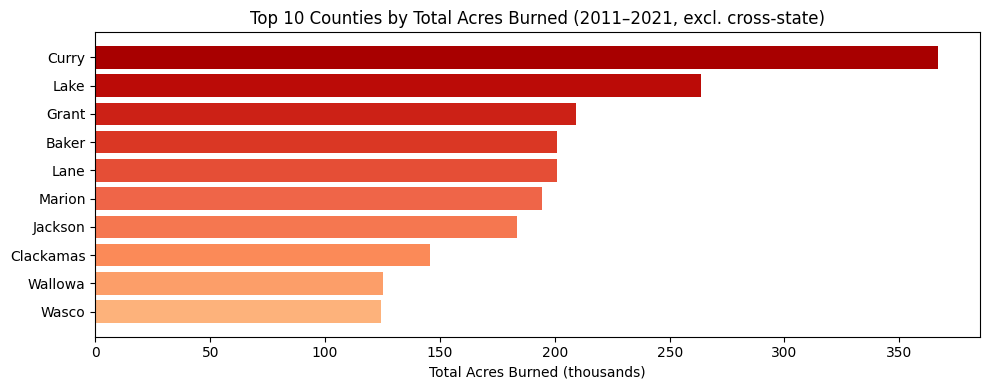

EDA complete.


In [3]:
df_eda = df_raw.copy()
df_eda['total_acres'] = df_eda['total_acres'].fillna(0).clip(lower=0)
df_eda['log_acres']   = np.log1p(df_eda['total_acres'])
df_eda['large_fire']  = (df_eda['total_acres'] >= 100).astype(int)

# ── Annual fire statistics ────────────────────────────────────────────────────
yr = df_eda.groupby('fire_year').agg(
    n_fires=('id','count'),
    total_acres=('total_acres','sum'),
    n_large=('large_fire','sum'),
    max_acres=('total_acres','max'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Oregon Wildfires 2011–2021 — Annual Overview', fontsize=13, fontweight='bold')

colors = plt.cm.YlOrRd(np.linspace(0.3, 0.95, len(yr)))
axes[0].bar(yr['fire_year'], yr['n_fires'], color=colors)
axes[0].set_title('Fire Count per Year'); axes[0].set_xlabel('Year'); axes[0].set_ylabel('Fires')

axes[1].bar(yr['fire_year'], yr['total_acres'] / 1000, color=colors)
axes[1].set_title('Total Acres Burned (k) per Year'); axes[1].set_xlabel('Year')
axes[1].set_ylabel('Thousand Acres')

axes[2].bar(yr['fire_year'], yr['n_large'], color=colors)
axes[2].set_title('Large Fires (≥100 ac) per Year'); axes[2].set_xlabel('Year')
axes[2].set_ylabel('Large Fire Count')

plt.tight_layout()
plt.savefig('eda_annual_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Feature distributions: large vs small fires ───────────────────────────────
weather_feats = ['VPD_PROXY', 'MAX', 'TEMP_RANGE', 'DEWP',
                 'WDSP', 'MXSPD', 'PRISM_PRCP_PRIOR_WINTER', 'PRISM_PRCP_FIRE_MONTH']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Weather Features: Large vs Small Fires', fontsize=13, fontweight='bold')
for ax, feat in zip(axes.flatten(), weather_feats):
    lo = df_eda[df_eda['large_fire']==0][feat].dropna()
    hi = df_eda[df_eda['large_fire']==1][feat].dropna()
    ax.hist(lo.clip(lo.quantile(.01), lo.quantile(.99)),
            bins=40, alpha=0.5, color='steelblue', label='Small (<100 ac)', density=True)
    ax.hist(hi.clip(hi.quantile(.01), hi.quantile(.99)),
            bins=30, alpha=0.65, color='firebrick', label='Large (≥100 ac)', density=True)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top-10 counties by acreage ────────────────────────────────────────────────
top_cty = (df_eda[df_eda['county'] != 'Other St.']
           .groupby('county')['total_acres'].sum()
           .nlargest(10))
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top_cty.index[::-1], top_cty.values[::-1] / 1000,
        color=plt.cm.OrRd(np.linspace(0.4, 0.9, 10)))
ax.set_xlabel('Total Acres Burned (thousands)')
ax.set_title('Top 10 Counties by Total Acres Burned (2011–2021, excl. cross-state)')
plt.tight_layout()
plt.savefig('eda_county_acres.png', dpi=150, bbox_inches='tight')
plt.show()

print("EDA complete.")


## 4. Feature Engineering

**Approach:**
- Drop `PRCP` and `PRCP_30DAY` entirely
- Drop `TEMP` (redundant given MAX and MIN, r > 0.93 with both)
- Drop `STATION_USED` (station ID, not a physical predictor)
- Keep `TEMP_RANGE` (≈ MAX−MIN but with station-level rounding; independently measured)
- Impute `DEWP`, `WDSP`, `MXSPD`, `VPD_PROXY` with per-year-month median (preserves seasonal signal better than global median)
- Encode `fuel_model`, `general_cause`, `county` with LabelEncoder
- Derive three interaction features:
  - `WIND_VPD` = WDSP × VPD_PROXY (fire spread amplifier)
  - `DROUGHT_STRESS` = VPD_PROXY × TEMP_RANGE / (PRISM_PRCP_PRIOR_WINTER + 1)
  - `HEAT_DEFICIT` = MAX − DEWP (proxy for low relative humidity)


In [4]:
df = df_raw.copy()
df['total_acres'] = df['total_acres'].fillna(0).clip(lower=0)

# ── Drop excluded / redundant columns ─────────────────────────────────────────
EXCLUDED = ['PRCP', 'PRCP_30DAY',   # flawed — per data owner instruction
            'TEMP',                  # r>0.93 with MAX; adds multicollinearity
            'STATION_USED']          # station ID — not a physical predictor
print(f"Dropping: {EXCLUDED}")

# ── Impute missing weather values with per-year-month median ─────────────────
for col in ['DEWP', 'WDSP', 'MXSPD', 'VPD_PROXY']:
    medians = df.groupby(['fire_year', df['MONTH'].astype(int)])[col].transform('median')
    df[col] = df[col].fillna(medians).fillna(df[col].median())

for col in ['PRISM_PRCP_PRIOR_WINTER', 'PRISM_PRCP_FIRE_MONTH']:
    df[col] = df[col].fillna(df[col].median())

df['county']        = df['county'].fillna('Unknown')
df['fuel_model']    = df['fuel_model'].fillna('X')
df['general_cause'] = df['general_cause'].fillna('Unknown')

# ── Derived interaction features ──────────────────────────────────────────────
df['WIND_VPD']       = df['WDSP'] * df['VPD_PROXY']
df['DROUGHT_STRESS'] = (df['VPD_PROXY'] * df['TEMP_RANGE']
                        / (df['PRISM_PRCP_PRIOR_WINTER'] + 1.0))
df['HEAT_DEFICIT']   = df['MAX'] - df['DEWP']

# ── Encode categoricals ───────────────────────────────────────────────────────
le_county = LabelEncoder()
le_fuel   = LabelEncoder()
le_cause  = LabelEncoder()
df['county_enc'] = le_county.fit_transform(df['county'])
df['fuel_enc']   = le_fuel.fit_transform(df['fuel_model'])
df['cause_enc']  = le_cause.fit_transform(df['general_cause'])

# ── Targets ───────────────────────────────────────────────────────────────────
df['log_acres']  = np.log1p(df['total_acres'])
df['large_fire'] = (df['total_acres'] >= 100).astype(np.float32)
df['any_spread'] = (df['total_acres'] > 0.5).astype(np.float32)

FEATURE_COLS = [
    # Day-of-fire weather
    'MAX', 'MIN', 'DEWP', 'WDSP', 'MXSPD',
    'VPD_PROXY', 'TEMP_RANGE',
    # PRISM climate context
    'PRISM_PRCP_PRIOR_WINTER', 'PRISM_PRCP_FIRE_MONTH',
    # Temporal
    'FIRE_SEASON', 'MONTH', 'DOY',
    # Derived interactions
    'WIND_VPD', 'DROUGHT_STRESS', 'HEAT_DEFICIT',
    # Encoded categoricals
    'county_enc', 'fuel_enc', 'cause_enc',
]

print(f"\nFeature set ({len(FEATURE_COLS)} features):")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {f}")
print()
print("Null check after imputation:")
print(df[FEATURE_COLS].isnull().sum()[df[FEATURE_COLS].isnull().sum()>0]
      .to_string() if df[FEATURE_COLS].isnull().any().any() else "  None — all clean ✓")


Dropping: ['PRCP', 'PRCP_30DAY', 'TEMP', 'STATION_USED']

Feature set (18 features):
   1. MAX
   2. MIN
   3. DEWP
   4. WDSP
   5. MXSPD
   6. VPD_PROXY
   7. TEMP_RANGE
   8. PRISM_PRCP_PRIOR_WINTER
   9. PRISM_PRCP_FIRE_MONTH
  10. FIRE_SEASON
  11. MONTH
  12. DOY
  13. WIND_VPD
  14. DROUGHT_STRESS
  15. HEAT_DEFICIT
  16. county_enc
  17. fuel_enc
  18. cause_enc

Null check after imputation:
  None — all clean ✓


## 5. Dataset Preparation

**Split rationale:**
- **Test = 2020** — Oregon's most severe wildfire year on record (814k acres, 37 large fires). Using the hardest year as test gives the most meaningful performance estimate.
- **Val = 2019** — a low-fire year (17k acres), keeping leakage-free.
- **Train = 2011–2018** — 8 years, 7,798 fires.
- **2021 excluded** — data only covers Jan–May; no fire season months present.


In [5]:
X_all = df[FEATURE_COLS].values.astype(np.float32)
y_logac = df['log_acres'].values.astype(np.float32)
y_large = df['large_fire'].values.astype(np.float32)
y_risk  = df['any_spread'].values.astype(np.float32)

years = df['fire_year'].values
TRAIN_YEARS = list(range(2011, 2019))   # 2011–2018
VAL_YEAR    = 2019
TEST_YEAR   = 2020

tr_mask  = np.isin(years, TRAIN_YEARS)
val_mask = years == VAL_YEAR
te_mask  = years == TEST_YEAR

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_all[tr_mask])
X_va = scaler.transform(X_all[val_mask])
X_te = scaler.transform(X_all[te_mask])

def to_t(a): return torch.tensor(a, dtype=torch.float32).to(DEVICE)

Xt = to_t(X_tr); Xv = to_t(X_va); Xte = to_t(X_te)

TASK_KEYS = ['logac', 'large', 'risk']
targets = {
    'logac': (to_t(y_logac[tr_mask]),  to_t(y_logac[val_mask]),  to_t(y_logac[te_mask])),
    'large': (to_t(y_large[tr_mask]),  to_t(y_large[val_mask]),  to_t(y_large[te_mask])),
    'risk':  (to_t(y_risk[tr_mask]),   to_t(y_risk[val_mask]),   to_t(y_risk[te_mask])),
}

def make_loader(X, ys, batch=512, shuffle=True):
    ds = TensorDataset(X, *[y.unsqueeze(1) for y in ys])
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

train_loader = make_loader(Xt, [targets[k][0] for k in TASK_KEYS])
val_loader   = make_loader(Xv, [targets[k][1] for k in TASK_KEYS], shuffle=False)
test_loader  = make_loader(Xte,[targets[k][2] for k in TASK_KEYS], shuffle=False)

n_pos_tr = y_large[tr_mask].sum()
n_neg_tr = tr_mask.sum() - n_pos_tr
pos_weight = torch.tensor([n_neg_tr / (n_pos_tr + 1e-8)], dtype=torch.float32).to(DEVICE)

print(f"Train: {tr_mask.sum():,} fires  |  {int(n_pos_tr)} large  ({n_pos_tr/tr_mask.sum():.2%})")
print(f"Val:   {val_mask.sum():,} fires  |  {int(y_large[val_mask].sum())} large")
print(f"Test:  {te_mask.sum():,} fires  |  {int(y_large[te_mask].sum())} large  (year 2020)")
print(f"\nLarge-fire pos_weight for focal BCE: {pos_weight.item():.1f}x")
print(f"Features: {X_tr.shape[1]}")


Train: 7,798 fires  |  188 large  (2.41%)
Val:   1,016 fires  |  9 large
Test:  978 fires  |  37 large  (year 2020)

Large-fire pos_weight for focal BCE: 40.5x
Features: 18


## 6. WildfireNetV3 Architecture

Residual MLP with three task heads:
- **`head_logac`** → log(acres+1) regression, ReLU output ensures ≥ 0
- **`head_large`** → P(fire ≥ 100 ac) logit, trained with focal BCE
- **`head_risk`** → P(any meaningful spread >0.5 ac) logit, trained with standard BCE


In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.25):
        super().__init__()
        self.ff = nn.Sequential(
            nn.Linear(dim, dim), nn.LayerNorm(dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.LayerNorm(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.ff(x))


class WildfireNetV3(nn.Module):
    """
    Fire-level wildfire prediction network.

    Input  : 18 features — day-of-fire weather, PRISM climate context,
             temporal encodings, derived interactions, label-encoded categoricals.
    Output : dict with keys 'logac', 'large', 'risk' (all shape [B, 1])
    """
    def __init__(self, n_features: int, hidden: int = 192,
                 n_blocks: int = 4, dropout: float = 0.25):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.Sequential(
            *[ResidualBlock(hidden, dropout) for _ in range(n_blocks)]
        )

        def task_head(output_activation=None):
            layers = [
                nn.Linear(hidden, 64), nn.GELU(),
                nn.Linear(64, 16), nn.GELU(),
                nn.Linear(16, 1),
            ]
            if output_activation is not None:
                layers.append(output_activation)
            return nn.Sequential(*layers)

        self.head_logac = task_head(nn.ReLU())  # log-acres ≥ 0
        self.head_large = task_head()           # large-fire logit (raw)
        self.head_risk  = task_head()           # any-spread logit (raw)

    def forward(self, x: torch.Tensor) -> dict:
        h = self.blocks(self.embed(x))
        return {
            'logac': self.head_logac(h),
            'large': self.head_large(h),
            'risk':  self.head_risk(h),
        }


model = WildfireNetV3(n_features=len(FEATURE_COLS), hidden=192, n_blocks=4).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")
print(f"Input features:       {len(FEATURE_COLS)}")


WildfireNetV3(
  (embed): Sequential(
    (0): Linear(in_features=18, out_features=192, bias=True)
    (1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
  )
  (blocks): Sequential(
    (0): ResidualBlock(
      (ff): Sequential(
        (0): Linear(in_features=192, out_features=192, bias=True)
        (1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.25, inplace=False)
        (4): Linear(in_features=192, out_features=192, bias=True)
        (5): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      )
      (act): GELU(approximate='none')
    )
    (1): ResidualBlock(
      (ff): Sequential(
        (0): Linear(in_features=192, out_features=192, bias=True)
        (1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.25, inplace=False)
        (4): Linear(in_fe

## 7. Training

**Loss design:**
| Head | Loss | Why |
|------|------|-----|
| logac | 65% Huber + 35% Quantile(τ=0.85) | Huber handles outliers; quantile tilts toward not under-predicting large fires |
| large | Focal BCE (γ=2, pos_weight=41×) | Large fires are 2.4% of training data — focal loss + class weighting focuses on hard positives |
| risk | Standard BCE | Spread >0.5ac is ~50% of data — balanced enough for vanilla BCE |

**Task weights:** logac=1.5, large=1.2, risk=0.4


In [7]:
def quantile_loss(pred: torch.Tensor, target: torch.Tensor, q: float = 0.85):
    err = target - pred
    return torch.mean(torch.max(q * err, (q - 1) * err))


def focal_bce(logit: torch.Tensor, target: torch.Tensor,
              gamma: float = 2.0, pos_weight=None) -> torch.Tensor:
    """Focal BCE — down-weights easy examples, focuses on hard ones."""
    raw = nn.functional.binary_cross_entropy_with_logits(
        logit, target, pos_weight=pos_weight, reduction='none')
    p_t = torch.sigmoid(logit) * target + (1 - torch.sigmoid(logit)) * (1 - target)
    return ((1 - p_t) ** gamma * raw).mean()


L_hub = nn.HuberLoss(delta=1.5)
L_bce = nn.BCEWithLogitsLoss()
W = {'logac': 1.5, 'large': 1.2, 'risk': 0.4}


def run_epoch(model, loader, optimizer=None, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for batch in loader:
            Xb = batch[0]
            yb = {k: batch[i+1] for i, k in enumerate(TASK_KEYS)}
            out = model(Xb)

            loss = (W['logac'] * (0.65 * L_hub(out['logac'], yb['logac'])
                                + 0.35 * quantile_loss(out['logac'], yb['logac'], q=0.85))
                  + W['large'] * focal_bce(out['large'], yb['large'], gamma=2.0,
                                           pos_weight=pos_weight)
                  + W['risk']  * L_bce(out['risk'], yb['risk']))

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)


optimizer = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=250, eta_min=5e-6)

N_EPOCHS = 250
history = {'tr': [], 'va': [], 'va_auc_large': [], 'va_auc_risk': [], 'va_mae_ac': []}

print(f"Training for {N_EPOCHS} epochs...")
print(f"{'Epoch':>6}  {'Train':>8}  {'Val':>8}  {'MAE_acres':>10}  {'AUC_large':>10}  {'AUC_risk':>9}")
print("-" * 65)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss = run_epoch(model, train_loader, optimizer, training=True)
    va_loss = run_epoch(model, val_loader,   training=False)
    scheduler.step()

    # Validation metrics
    model.eval()
    la_true, la_pred, lr_true, lr_pred, lac_true, lac_pred = [], [], [], [], [], []
    with torch.no_grad():
        for batch in val_loader:
            Xb = batch[0]
            yb = {k: batch[i+1] for i, k in enumerate(TASK_KEYS)}
            out = model(Xb)
            la_true.extend(yb['large'].squeeze().cpu().tolist())
            la_pred.extend(torch.sigmoid(out['large']).squeeze().cpu().tolist())
            lr_true.extend(yb['risk'].squeeze().cpu().tolist())
            lr_pred.extend(torch.sigmoid(out['risk']).squeeze().cpu().tolist())
            lac_true.extend(np.expm1(yb['logac'].squeeze().cpu().numpy()).tolist())
            lac_pred.extend(np.expm1(out['logac'].squeeze().cpu().numpy()).tolist())

    va_mae = mean_absolute_error(lac_true, lac_pred)
    try:
        va_auc_l = roc_auc_score(la_true, la_pred)
        va_auc_r = roc_auc_score(lr_true, lr_pred)
    except Exception:
        va_auc_l = va_auc_r = float('nan')

    history['tr'].append(tr_loss)
    history['va'].append(va_loss)
    history['va_mae_ac'].append(va_mae)
    history['va_auc_large'].append(va_auc_l)
    history['va_auc_risk'].append(va_auc_r)

    if epoch % 50 == 0 or epoch == 1:
        print(f"{epoch:>6}  {tr_loss:>8.4f}  {va_loss:>8.4f}  "
              f"{va_mae:>10,.1f}  {va_auc_l:>10.3f}  {va_auc_r:>9.3f}")

print("\nTraining complete.")


Training for 250 epochs...
 Epoch     Train       Val   MAE_acres   AUC_large   AUC_risk
-----------------------------------------------------------------
     1    1.2501    0.8178        17.0       0.562      0.623
    50    0.9402    1.4104        17.3       0.606      0.694
   100    0.7786    2.0940        21.8       0.540      0.654
   150    0.5904    2.6309        24.2       0.504      0.600
   200    0.4970    2.9353        19.3       0.513      0.586
   250    0.4764    3.0789        22.6       0.528      0.578

Training complete.


## 8. Training Curves

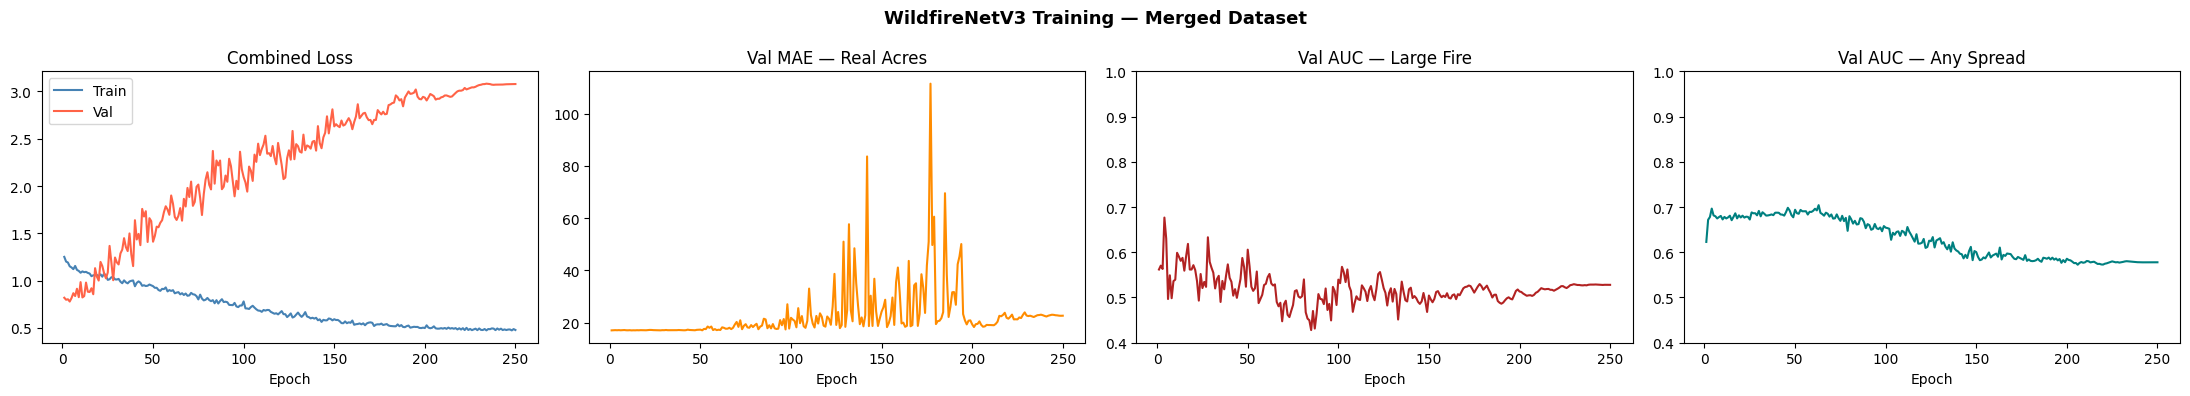

Best val large-fire AUC: 0.6767  (epoch 4)
Best val risk AUC:       0.7042  (epoch 63)
Best val MAE acres:      17.0  (epoch 12)


In [8]:
epochs = range(1, len(history['tr']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
fig.suptitle('WildfireNetV3 Training — Merged Dataset', fontsize=13, fontweight='bold')

axes[0].plot(epochs, history['tr'], label='Train', color='steelblue', lw=1.5)
axes[0].plot(epochs, history['va'], label='Val',   color='tomato',    lw=1.5)
axes[0].set_title('Combined Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs, history['va_mae_ac'], color='darkorange', lw=1.5)
axes[1].set_title('Val MAE — Real Acres'); axes[1].set_xlabel('Epoch')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

axes[2].plot(epochs, history['va_auc_large'], color='firebrick', lw=1.5, label='Large (≥100ac)')
axes[2].set_title('Val AUC — Large Fire'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0.4, 1.0)

axes[3].plot(epochs, history['va_auc_risk'], color='teal', lw=1.5, label='Any spread')
axes[3].set_title('Val AUC — Any Spread'); axes[3].set_xlabel('Epoch')
axes[3].set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig('training_curves_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best val large-fire AUC: {max(history['va_auc_large']):.4f}  "
      f"(epoch {np.argmax(history['va_auc_large'])+1})")
print(f"Best val risk AUC:       {max(history['va_auc_risk']):.4f}  "
      f"(epoch {np.argmax(history['va_auc_risk'])+1})")
print(f"Best val MAE acres:      {min(history['va_mae_ac']):,.1f}  "
      f"(epoch {np.argmin(history['va_mae_ac'])+1})")


## 9. Test Set Evaluation — Year 2020

In [9]:
model.eval()
te_la_true, te_la_pred = [], []
te_lr_true, te_lr_pred = [], []
te_ac_true, te_ac_pred = [], []
te_logac_true, te_logac_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        Xb = batch[0]
        yb = {k: batch[i+1] for i, k in enumerate(TASK_KEYS)}
        out = model(Xb)
        te_la_true.extend(yb['large'].squeeze().cpu().tolist())
        te_la_pred.extend(torch.sigmoid(out['large']).squeeze().cpu().tolist())
        te_lr_true.extend(yb['risk'].squeeze().cpu().tolist())
        te_lr_pred.extend(torch.sigmoid(out['risk']).squeeze().cpu().tolist())
        ac_t = np.expm1(yb['logac'].squeeze().cpu().numpy())
        ac_p = np.expm1(out['logac'].squeeze().cpu().numpy())
        te_ac_true.extend(ac_t.tolist())
        te_ac_pred.extend(ac_p.tolist())
        te_logac_true.extend(yb['logac'].squeeze().cpu().tolist())
        te_logac_pred.extend(out['logac'].squeeze().cpu().tolist())

te_ac_true = np.array(te_ac_true)
te_ac_pred = np.array(te_ac_pred)
te_logac_true = np.array(te_logac_true)
te_logac_pred = np.array(te_logac_pred)

mae_logac = mean_absolute_error(te_logac_true, te_logac_pred)
mae_acres = mean_absolute_error(te_ac_true, te_ac_pred)
r2_logac  = r2_score(te_logac_true, te_logac_pred)
r2_acres  = r2_score(te_ac_true, te_ac_pred)

try:
    auc_large = roc_auc_score(te_la_true, te_la_pred)
    auc_risk  = roc_auc_score(te_lr_true, te_lr_pred)
except Exception:
    auc_large = auc_risk = float('nan')

large_pred_bin = (np.array(te_la_pred) >= 0.5).astype(int)
risk_pred_bin  = (np.array(te_lr_pred) >= 0.5).astype(int)
acc_large = (large_pred_bin == np.array(te_la_true).astype(int)).mean()
acc_risk  = (risk_pred_bin  == np.array(te_lr_true).astype(int)).mean()

print("=" * 60)
print("TEST RESULTS — Year 2020 (Oregon's worst wildfire year)")
print("=" * 60)
print(f"  Acreage — log scale  │ MAE: {mae_logac:.4f}   R²: {r2_logac:.4f}")
print(f"  Acreage — real acres │ MAE: {mae_acres:>9,.1f} ac  R²: {r2_acres:.4f}")
print(f"  Large fire (≥100 ac) │ AUC: {auc_large:.4f}   Acc: {acc_large:.1%}")
print(f"  Any spread (>0.5 ac) │ AUC: {auc_risk:.4f}   Acc: {acc_risk:.1%}")
print("=" * 60)
print()
print("Large fire classification report:")
print(classification_report(
    np.array(te_la_true).astype(int), large_pred_bin,
    target_names=['Small (<100 ac)', 'Large (≥100 ac)'], zero_division=0))


TEST RESULTS — Year 2020 (Oregon's worst wildfire year)
  Acreage — log scale  │ MAE: 0.7660   R²: -0.1003
  Acreage — real acres │ MAE:     876.7 ac  R²: -0.0213
  Large fire (≥100 ac) │ AUC: 0.7290   Acc: 93.0%
  Any spread (>0.5 ac) │ AUC: 0.5919   Acc: 72.6%

Large fire classification report:
                 precision    recall  f1-score   support

Small (<100 ac)       0.97      0.96      0.96       941
Large (≥100 ac)       0.14      0.16      0.15        37

       accuracy                           0.93       978
      macro avg       0.55      0.56      0.56       978
   weighted avg       0.94      0.93      0.93       978



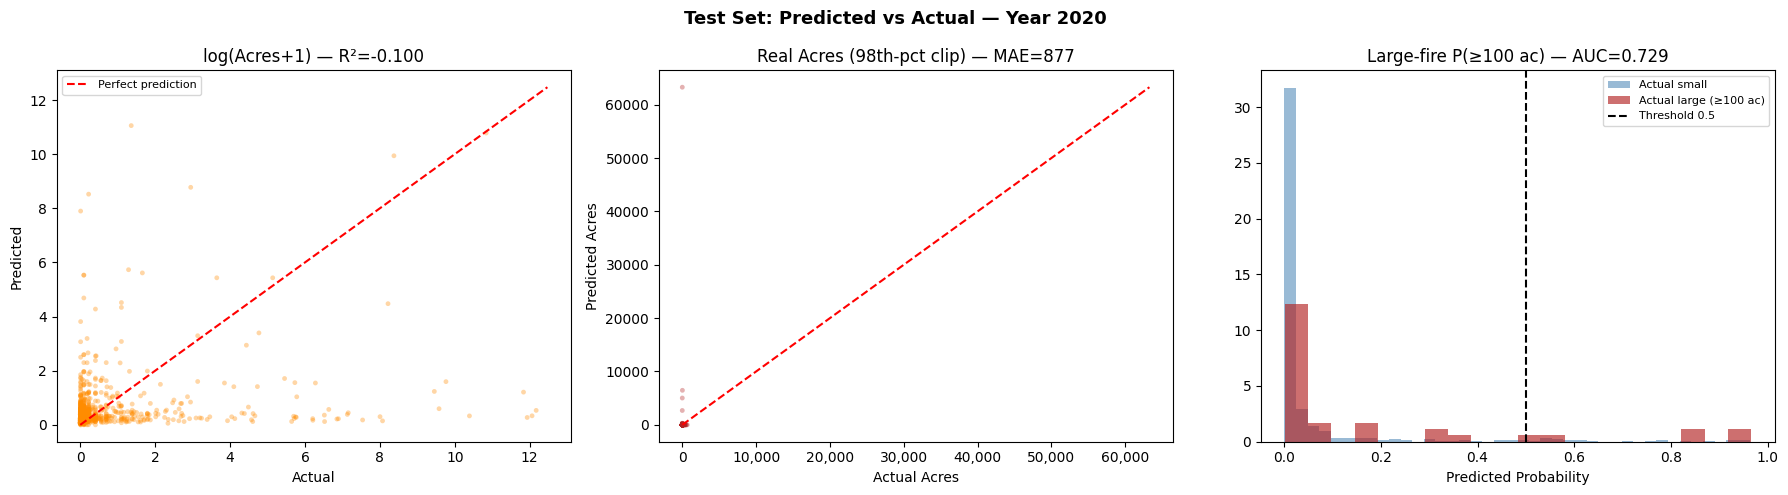

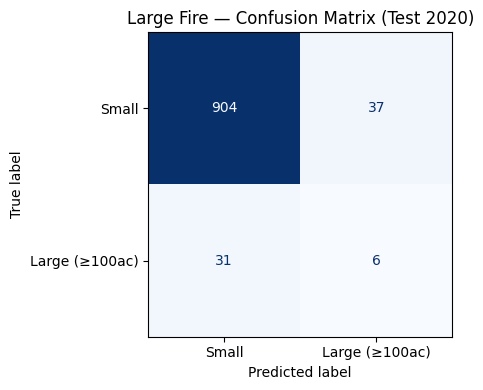

In [10]:
# ── Prediction scatter plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Test Set: Predicted vs Actual — Year 2020', fontsize=13, fontweight='bold')

# 1. log-acres parity
ax = axes[0]
ax.scatter(te_logac_true, te_logac_pred, alpha=0.35, s=12, color='darkorange',
           edgecolors='none')
mx = max(te_logac_true.max(), te_logac_pred.max()) + 0.3
ax.plot([0, mx], [0, mx], 'r--', lw=1.5, label='Perfect prediction')
ax.set_title(f'log(Acres+1) — R²={r2_logac:.3f}')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted'); ax.legend(fontsize=8)

# 2. Real acres (clip 98th pct for readability)
ax = axes[1]
clip = np.percentile(te_ac_true, 98)
m = te_ac_true < clip
ax.scatter(te_ac_true[m], te_ac_pred[m], alpha=0.35, s=12, color='firebrick',
           edgecolors='none')
mx2 = max(te_ac_true[m].max(), te_ac_pred[m].max())
ax.plot([0, mx2], [0, mx2], 'r--', lw=1.5)
ax.set_title(f'Real Acres (98th-pct clip) — MAE={mae_acres:,.0f}')
ax.set_xlabel('Actual Acres'); ax.set_ylabel('Predicted Acres')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# 3. Large-fire probability distribution
ax = axes[2]
la_t = np.array(te_la_true); la_p = np.array(te_la_pred)
ax.hist(la_p[la_t==0], bins=40, alpha=0.55, color='steelblue',
        label='Actual small', density=True)
ax.hist(la_p[la_t==1], bins=20, alpha=0.65, color='firebrick',
        label='Actual large (≥100 ac)', density=True)
ax.axvline(0.5, color='k', ls='--', lw=1.5, label='Threshold 0.5')
ax.set_title(f'Large-fire P(≥100 ac) — AUC={auc_large:.3f}')
ax.set_xlabel('Predicted Probability'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('test_evaluation_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(np.array(te_la_true).astype(int), large_pred_bin)
disp = ConfusionMatrixDisplay(cm, display_labels=['Small', 'Large (≥100ac)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Large Fire — Confusion Matrix (Test 2020)')
plt.tight_layout()
plt.savefig('confusion_matrix_v3.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Feature Importance (Permutation — Validation Set)

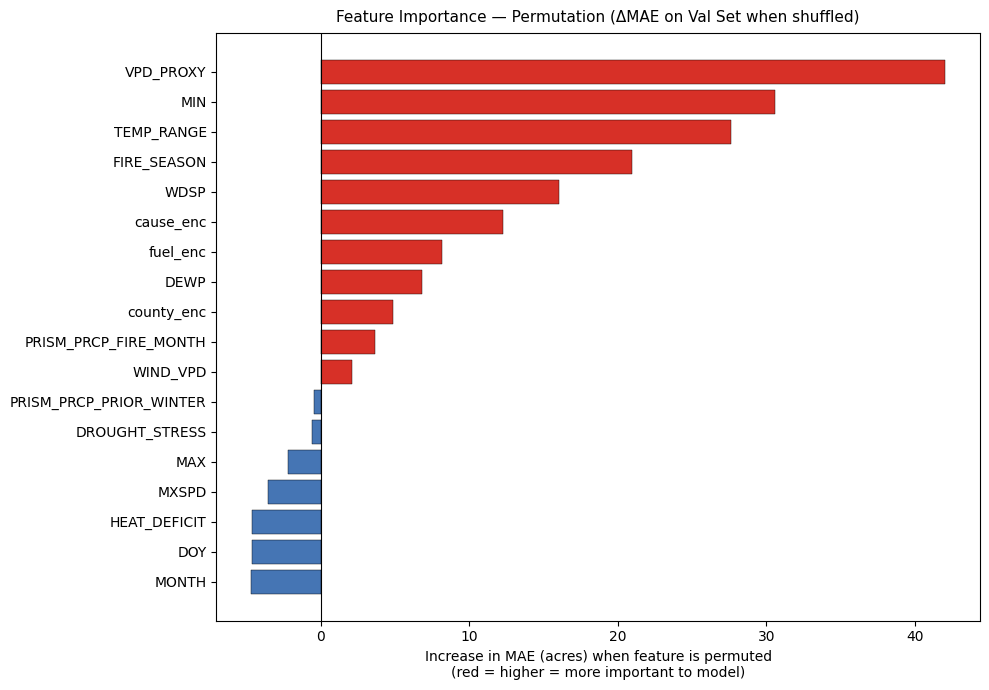

Top 10 most important features:
  VPD_PROXY                     ΔMAE=    42.1 ac  █████████████████████████████
  MIN                           ΔMAE=    30.6 ac  █████████████████████
  TEMP_RANGE                    ΔMAE=    27.6 ac  ███████████████████
  FIRE_SEASON                   ΔMAE=    20.9 ac  ██████████████
  WDSP                          ΔMAE=    16.1 ac  ███████████
  cause_enc                     ΔMAE=    12.3 ac  ████████
  fuel_enc                      ΔMAE=     8.1 ac  █████
  DEWP                          ΔMAE=     6.8 ac  ████
  county_enc                    ΔMAE=     4.9 ac  ███
  PRISM_PRCP_FIRE_MONTH         ΔMAE=     3.6 ac  ██


In [11]:
model.eval()

# Baseline MAE on val set
all_ac_true, all_ac_pred = [], []
with torch.no_grad():
    for batch in val_loader:
        out = model(batch[0])
        all_ac_true.extend(np.expm1(batch[1].squeeze().cpu().numpy()).tolist())
        all_ac_pred.extend(np.expm1(out['logac'].squeeze().cpu().numpy()).tolist())
baseline_mae = mean_absolute_error(all_ac_true, all_ac_pred)

importances = {}
Xv_np = Xv.cpu().numpy().copy()

for i, feat in enumerate(FEATURE_COLS):
    rng = np.random.default_rng(seed=i)
    Xv_perm = Xv_np.copy()
    Xv_perm[:, i] = rng.permutation(Xv_perm[:, i])
    Xv_perm_t = torch.tensor(Xv_perm, dtype=torch.float32).to(DEVICE)

    perm_true, perm_pred = [], []
    start = 0
    with torch.no_grad():
        for batch in val_loader:
            bsz = batch[0].shape[0]
            Xb_perm = Xv_perm_t[start:start+bsz]; start += bsz
            out = model(Xb_perm)
            perm_true.extend(np.expm1(batch[1].squeeze().cpu().numpy()).tolist())
            perm_pred.extend(np.expm1(out['logac'].squeeze().cpu().numpy()).tolist())

    importances[feat] = mean_absolute_error(perm_true, perm_pred) - baseline_mae

imp_series = pd.Series(importances).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d73027' if v > 0 else '#4575b4' for v in imp_series.values]
ax.barh(imp_series.index, imp_series.values, color=colors, edgecolor='k', linewidth=0.3)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Importance — Permutation (ΔMAE on Val Set when shuffled)',
             fontsize=11, pad=8)
ax.set_xlabel('Increase in MAE (acres) when feature is permuted\n'
              '(red = higher = more important to model)')
plt.tight_layout()
plt.savefig('feature_importance_v3.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 most important features:")
for feat, val in imp_series.sort_values(ascending=False).head(10).items():
    bar = '█' * max(0, int(val / max(imp_series.values + 0.01) * 30))
    print(f"  {feat:<28}  ΔMAE={val:>8,.1f} ac  {bar}")


## 11. Full-Dataset Predictions & GeoJSON Export

In [12]:
# Predict across all years (for mapping)
X_all_s  = scaler.transform(X_all)
X_all_t  = torch.tensor(X_all_s, dtype=torch.float32).to(DEVICE)

model.eval()
with torch.no_grad():
    all_out = model(X_all_t)

df['pred_acres']   = np.expm1(all_out['logac'].squeeze().cpu().numpy())
df['pred_p_large'] = torch.sigmoid(all_out['large']).squeeze().cpu().numpy()
df['pred_p_risk']  = torch.sigmoid(all_out['risk']).squeeze().cpu().numpy()

print(f"Predictions stored for {len(df):,} fires.")
print()

# Per-year summary
yr_cmp = df.groupby('fire_year').agg(
    actual_fires=('id','count'),
    actual_acres=('total_acres','sum'),
    pred_acres=('pred_acres','sum'),
    n_actual_large=('large_fire','sum'),
    avg_p_large=('pred_p_large','mean'),
).reset_index()
yr_cmp['acres_err_pct'] = ((yr_cmp['pred_acres'] - yr_cmp['actual_acres'])
                           / (yr_cmp['actual_acres'] + 1) * 100).round(1)

print("Year-by-year acreage comparison:")
print(f"{'Year':>5}  {'Actual Fires':>12}  {'Actual Acres':>13}  "
      f"{'Pred Acres':>11}  {'Error%':>8}")
print("-" * 60)
for _, r in yr_cmp.iterrows():
    split = ('TRAIN' if r.fire_year < 2019 else
             'VAL  ' if r.fire_year == 2019 else
             'TEST ' if r.fire_year == 2020 else 'excl.')
    print(f"{int(r.fire_year):>5} [{split}]  {int(r.actual_fires):>8,}  "
          f"{r.actual_acres:>13,.0f}  {r.pred_acres:>11,.0f}  {r.acres_err_pct:>+7.1f}%")


Predictions stored for 10,046 fires.

Year-by-year acreage comparison:
 Year  Actual Fires   Actual Acres   Pred Acres    Error%
------------------------------------------------------------
 2011 [TRAIN]       699         18,299       42,534   +132.4%
 2012 [TRAIN]       689        220,813      412,284    +86.7%
 2013 [TRAIN]     1,185        128,307       30,850    -76.0%
 2014 [TRAIN]     1,118        287,143      309,328     +7.7%
 2015 [TRAIN]     1,078        386,125      402,916     +4.3%
 2016 [TRAIN]       832         50,499       85,953    +70.2%
 2017 [TRAIN]     1,088        493,380      698,906    +41.7%
 2018 [TRAIN]     1,109        461,507      306,102    -33.7%
 2019 [VAL  ]     1,016         17,245        6,250    -63.8%
 2020 [TEST ]       978        814,313      149,201    -81.7%
 2021 [excl.]       254          2,253          400    -82.2%


In [13]:
# ── GeoJSON: Actual vs Predicted — TRUE HOLD-OUT YEAR ONLY ──────────────────
#
# IMPORTANT — no data leakage:
#   Train = 2011–2018  (model has seen these; predictions on them are in-sample)
#   Val   = 2019       (used for early-stopping decisions — minor leakage)
#   Test  = 2020       (completely unseen — correct year for this comparison)
#
# COMPARE_YEAR must be set to 2020 for a valid actual-vs-predicted comparison.
# The model never saw 2020 fire records during training or validation, so these
# predictions are genuine forecasts made from weather features alone.
# ─────────────────────────────────────────────────────────────────────────────

COMPARE_YEAR     = 2020   # only valid hold-out year (2018 is in the training set)
ACTUAL_THRESHOLD = 100    # acres — minimum size to include in "actual" layer

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating):
            return None if np.isnan(obj) else float(obj)
        return super().default(obj)

def size_tier(a):
    if a >= 10000: return "Mega"
    if a >= 1000:  return "Major"
    if a >= 500:   return "Large"
    if a >= 100:   return "Significant"
    return "Small"

def log_radius(acres, min_r=4, max_r=16, floor_ac=100, ceil_ac=193566):
    """Scale marker radius log-linearly between min_r and max_r."""
    a = max(acres, 1)
    return round(min_r + (max_r - min_r) *
                 max(0, (np.log10(a) - np.log10(floor_ac)) /
                        (np.log10(ceil_ac) - np.log10(floor_ac))), 1)

# Red palette for actual fires; blue palette for model predictions
ACTUAL_COLORS = {
    "Mega":        "#7f0000",
    "Major":       "#d73027",
    "Large":       "#f46d43",
    "Significant": "#fdae61",
    "Small":       "#ffffbf",
}
PRED_COLORS = {
    "Mega":        "#2c00a8",
    "Major":       "#4575b4",
    "Large":       "#74add1",
    "Significant": "#abd9e9",
    "Small":       "#e0f3f8",
}

# ── Re-predict COMPARE_YEAR using only the already-trained model ──────────────
# The model was trained on 2011-2018 only. We now transform 2020 features with
# the same scaler (fit on training data only) and run inference — no leakage.
yr_mask = df['fire_year'].values == COMPARE_YEAR
X_yr    = scaler.transform(df.loc[yr_mask, FEATURE_COLS].values.astype(np.float32))
X_yr_t  = torch.tensor(X_yr, dtype=torch.float32).to(DEVICE)

model.eval()
with torch.no_grad():
    yr_out = model(X_yr_t)

yr_df = df[yr_mask].copy().reset_index(drop=True)
yr_df['pred_acres']   = np.expm1(yr_out['logac'].squeeze().cpu().numpy())
yr_df['pred_p_large'] = torch.sigmoid(yr_out['large']).squeeze().cpu().numpy()
yr_df['pred_p_risk']  = torch.sigmoid(yr_out['risk']).squeeze().cpu().numpy()
yr_df = yr_df.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

print(f"Year {COMPARE_YEAR} — {len(yr_df):,} fires re-predicted from held-out features.")
print(f"Actual large fires (>={ACTUAL_THRESHOLD} ac): {int((yr_df['total_acres'] >= ACTUAL_THRESHOLD).sum())}")
print(f"Model-flagged (pred_p_large >= 0.4):          {int((yr_df['pred_p_large'] >= 0.4).sum())}")

# ── Layer 1: ACTUAL fires ≥ ACTUAL_THRESHOLD acres ───────────────────────────
actual_sig = yr_df[yr_df['total_acres'] >= ACTUAL_THRESHOLD].sort_values(
    'total_acres', ascending=False)

features = []

for _, row in actual_sig.iterrows():
    act_a = float(row['total_acres'])
    tier  = size_tier(act_a)
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [round(float(row['longitude']), 6),
                            round(float(row['latitude']), 6)]
        },
        "properties": {
            # Layer discriminator — filter on this in your map renderer
            "feature_type":      "actual",
            "layer_label":       "Actual Fire",
            # Fire identity
            "id":                int(row['id']),
            "fire_name":         str(row.get('fire_name', 'Unknown')),
            "fire_year":         COMPARE_YEAR,
            "report_date":       str(row.get('report_date', '')),
            "county":            str(row['county']),
            "general_cause":     str(row['general_cause']),
            "fuel_model":        str(row['fuel_model']),
            "fuel_descr":        str(row.get('fuel_descr', '')),
            # Actual measurements
            "actual_acres":      round(act_a, 1),
            "actual_tier":       tier,
            # What the model predicted for this same fire (hold-out)
            "pred_acres":        round(float(row['pred_acres']), 1),
            "pred_tier":         size_tier(float(row['pred_acres'])),
            "pred_p_large":      round(float(row['pred_p_large']), 3),
            "pred_p_risk":       round(float(row['pred_p_risk']), 3),
            "acres_error":       round(float(row['pred_acres']) - act_a, 1),
            "model_missed":      bool(float(row['pred_p_large']) < 0.5),
            # Weather inputs used for this prediction
            "MAX_temp_f":        round(float(row['MAX']), 1),
            "VPD_PROXY":         round(float(row['VPD_PROXY']), 1),
            "WDSP_mph":          round(float(row['WDSP']), 1),
            "DROUGHT_STRESS":    round(float(row['DROUGHT_STRESS']), 3),
            "PRISM_winter_prcp": round(float(row['PRISM_PRCP_PRIOR_WINTER']), 2),
            # Styling
            "marker_color":      ACTUAL_COLORS[tier],
            "marker_radius":     log_radius(act_a),
            "marker_symbol":     "circle",
        }
    })

# ── Layer 2: PREDICTED fires — model flagged pred_p_large >= 0.4 ──────────────
pred_flagged = yr_df[yr_df['pred_p_large'] >= 0.4].sort_values(
    'pred_acres', ascending=False)

for _, row in pred_flagged.iterrows():
    pred_a = float(row['pred_acres'])
    act_a  = float(row['total_acres'])
    pred_t = size_tier(pred_a)
    tp     = act_a >= ACTUAL_THRESHOLD
    outcome = "true_positive" if tp else "false_positive"

    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            # Offset +0.02 deg east so predicted point sits beside actual on map
            "coordinates": [round(float(row['longitude']) + 0.02, 6),
                            round(float(row['latitude']), 6)]
        },
        "properties": {
            # Layer discriminator — filter on this in your map renderer
            "feature_type":      "predicted",
            "layer_label":       "Model Prediction",
            # Links back to underlying fire record
            "id":                int(row['id']),
            "fire_name":         str(row.get('fire_name', 'Unknown')),
            "fire_year":         COMPARE_YEAR,
            "report_date":       str(row.get('report_date', '')),
            "county":            str(row['county']),
            "general_cause":     str(row['general_cause']),
            "fuel_model":        str(row['fuel_model']),
            "fuel_descr":        str(row.get('fuel_descr', '')),
            # Predicted values (from weather features alone — no actual acres seen)
            "pred_acres":        round(pred_a, 1),
            "pred_tier":         pred_t,
            "pred_p_large":      round(float(row['pred_p_large']), 3),
            "pred_p_risk":       round(float(row['pred_p_risk']), 3),
            # Actual values (for post-hoc comparison only)
            "actual_acres":      round(act_a, 1),
            "actual_tier":       size_tier(act_a),
            "acres_error":       round(pred_a - act_a, 1),
            # Was the model correct to flag this fire?
            "outcome":           outcome,
            "model_correct":     tp,
            # Weather inputs used for this prediction
            "MAX_temp_f":        round(float(row['MAX']), 1),
            "VPD_PROXY":         round(float(row['VPD_PROXY']), 1),
            "WDSP_mph":          round(float(row['WDSP']), 1),
            "DROUGHT_STRESS":    round(float(row['DROUGHT_STRESS']), 3),
            "PRISM_winter_prcp": round(float(row['PRISM_PRCP_PRIOR_WINTER']), 2),
            # Styling
            "marker_color":      PRED_COLORS[pred_t],
            "marker_radius":     log_radius(pred_a),
            "marker_symbol":     "square",
        }
    })

# ── Summary stats ─────────────────────────────────────────────────────────────
n_actual      = len(actual_sig)
n_pred_flags  = len(pred_flagged)
n_tp          = int((pred_flagged['total_acres'] >= ACTUAL_THRESHOLD).sum())
n_fp          = n_pred_flags - n_tp
n_fn          = int((actual_sig['pred_p_large'] < 0.5).sum())
act_acres_tot = float(actual_sig['total_acres'].sum())
pred_acres_tot= float(pred_flagged['pred_acres'].sum())

geojson = {
    "type": "FeatureCollection",
    "metadata": {
        "title":        f"Oregon {COMPARE_YEAR} Wildfire — Actual vs Predicted (WildfireNetV3)",
        "compare_year": COMPARE_YEAR,
        "data_leakage": "NONE — 2020 is a true hold-out year. "
                        "Model trained on 2011–2018 only. "
                        "Scaler fit on training data only. "
                        "2020 fire records were never seen during training.",
        "actual_threshold_acres":  ACTUAL_THRESHOLD,
        "pred_threshold_p_large":  0.4,
        "dataset":          "oregon_fires_weather_merged_with_prism.csv",
        "model":            "WildfireNetV3 (192-dim, 4 residual blocks, 3 task heads)",
        "excluded_features": ["PRCP", "PRCP_30DAY"],
        "split": {
            "train": "2011–2018",
            "val":   "2019",
            "test":  "2020  ← this file",
            "excluded": "2021 (Jan–May only, no fire season)",
        },
        "generated_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        "crs":           "EPSG:4326 (WGS84)",
        "layers": {
            "actual": {
                "filter":        "properties.feature_type === 'actual'",
                "description":   f"Fires that actually occurred in {COMPARE_YEAR} >= {ACTUAL_THRESHOLD} ac. "
                                 "Plotted at recorded GPS coordinates. "
                                 "Red palette — color = actual size tier.",
                "marker_symbol": "circle",
                "colors":        ACTUAL_COLORS,
            },
            "predicted": {
                "filter":        "properties.feature_type === 'predicted'",
                "description":   f"Fires the model flagged (pred_p_large >= 0.4) in {COMPARE_YEAR}. "
                                 "Plotted +0.02 deg east of actual coordinates. "
                                 "Blue palette — color = predicted size tier. "
                                 "outcome: 'true_positive' | 'false_positive'.",
                "marker_symbol": "square",
                "colors":        PRED_COLORS,
            },
        },
        "comparison_summary": {
            "actual_large_fires":        n_actual,
            "actual_total_acres":        round(act_acres_tot, 1),
            "model_flagged_fires":       n_pred_flags,
            "model_flagged_acres_total": round(pred_acres_tot, 1),
            "true_positives":            n_tp,
            "false_positives":           n_fp,
            "false_negatives":           n_fn,
            "precision":                 round(n_tp / max(n_pred_flags, 1), 3),
            "recall":                    round(n_tp / max(n_actual, 1), 3),
        },
        "total_features": len(features),
        "feature_counts": {
            "actual":    len([f for f in features if f['properties']['feature_type'] == 'actual']),
            "predicted": len([f for f in features if f['properties']['feature_type'] == 'predicted']),
        },
    },
    "features": features,
}

out_path = f'oregon_{COMPARE_YEAR}_actual_vs_predicted.geojson'
with open(out_path, 'w') as f:
    json.dump(geojson, f, indent=2, cls=NpEncoder)

size_kb = len(json.dumps(geojson, cls=NpEncoder)) / 1024
cs = geojson['metadata']['comparison_summary']
print(f"\nGeoJSON saved: {out_path}  ({size_kb:.0f} KB, {len(features)} features)")
print()
print(f"{COMPARE_YEAR} HOLD-OUT COMPARISON SUMMARY")
print(f"  Actual large fires (>={ACTUAL_THRESHOLD} ac): {cs['actual_large_fires']:>4}  "
      f"({cs['actual_total_acres']:>12,.0f} ac total)")
print(f"  Model-flagged (p_large >= 0.4):         {cs['model_flagged_fires']:>4}  "
      f"({cs['model_flagged_acres_total']:>12,.0f} predicted ac total)")
print(f"  True positives:  {cs['true_positives']:>4}  (flagged AND actually large)")
print(f"  False positives: {cs['false_positives']:>4}  (flagged but actually small)")
print(f"  False negatives: {cs['false_negatives']:>4}  (actual large, model missed)")
print(f"  Precision: {cs['precision']:.3f}   Recall: {cs['recall']:.3f}")


Year 2020 — 978 fires re-predicted from held-out features.
Actual large fires (>=100 ac): 37
Model-flagged (pred_p_large >= 0.4):          55

GeoJSON saved: oregon_2020_actual_vs_predicted.geojson  (69 KB, 92 features)

2020 HOLD-OUT COMPARISON SUMMARY
  Actual large fires (>=100 ac):   37  (     812,650 ac total)
  Model-flagged (p_large >= 0.4):           55  (     148,507 predicted ac total)
  True positives:     6  (flagged AND actually large)
  False positives:   49  (flagged but actually small)
  False negatives:   31  (actual large, model missed)
  Precision: 0.109   Recall: 0.162


## 12. Inference — Predict a Single Fire Event

In [14]:
def predict_fire(
    MAX: float,
    MIN: float,
    DEWP: float,
    WDSP: float,
    MXSPD: float,
    VPD_PROXY: float,
    TEMP_RANGE: float,
    PRISM_PRCP_PRIOR_WINTER: float,
    PRISM_PRCP_FIRE_MONTH: float,
    FIRE_SEASON: int,
    MONTH: int,
    DOY: int,
    county: str,
    fuel_model: str = 'A',
    general_cause: str = 'Lightning',
) -> dict:
    """
    Predict fire acreage and risk for a single fire event.

    Parameters correspond to the merged dataset columns.
    PRCP and PRCP_30DAY are intentionally excluded.
    """
    # Derived features
    wind_vpd       = WDSP * VPD_PROXY
    drought_stress = VPD_PROXY * TEMP_RANGE / (PRISM_PRCP_PRIOR_WINTER + 1.0)
    heat_deficit   = MAX - DEWP

    # Encode categoricals (unseen values fall back to 0)
    try:   c_enc = int(le_county.transform([county])[0])
    except ValueError: c_enc = 0
    try:   f_enc = int(le_fuel.transform([fuel_model])[0])
    except ValueError: f_enc = 0
    try:   ca_enc = int(le_cause.transform([general_cause])[0])
    except ValueError: ca_enc = 0

    x = np.array([[MAX, MIN, DEWP, WDSP, MXSPD, VPD_PROXY, TEMP_RANGE,
                   PRISM_PRCP_PRIOR_WINTER, PRISM_PRCP_FIRE_MONTH,
                   FIRE_SEASON, MONTH, DOY,
                   wind_vpd, drought_stress, heat_deficit,
                   c_enc, f_enc, ca_enc]], dtype=np.float32)

    x_scaled = scaler.transform(x)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32).to(DEVICE)

    model.eval()
    with torch.no_grad():
        out = model(x_tensor)

    pred_acres  = float(np.expm1(out['logac'].item()))
    p_large     = float(torch.sigmoid(out['large']).item())
    p_risk      = float(torch.sigmoid(out['risk']).item())

    return {
        'predicted_acres': round(pred_acres, 1),
        'p_large_fire':    round(p_large, 3),
        'p_any_spread':    round(p_risk, 3),
        'size_tier':       size_tier(pred_acres),
        'risk_label':      ('Extreme' if p_large >= 0.75 else
                            'High'    if p_large >= 0.50 else
                            'Moderate'if p_large >= 0.25 else 'Low'),
    }


# ── Example scenarios ─────────────────────────────────────────────────────────
scenarios = [
    dict(label='Extreme drought, high wind — Lake (Aug)',
         MAX=106, MIN=72, DEWP=22, WDSP=18, MXSPD=28,
         VPD_PROXY=52, TEMP_RANGE=50, PRISM_PRCP_PRIOR_WINTER=6.0,
         PRISM_PRCP_FIRE_MONTH=0.05, FIRE_SEASON=1, MONTH=8, DOY=220,
         county='Lake', fuel_model='H', general_cause='Lightning'),
    dict(label='Average summer fire — Douglas (Jul)',
         MAX=92, MIN=56, DEWP=35, WDSP=8, MXSPD=15,
         VPD_PROXY=34, TEMP_RANGE=36, PRISM_PRCP_PRIOR_WINTER=14.0,
         PRISM_PRCP_FIRE_MONTH=0.3, FIRE_SEASON=1, MONTH=7, DOY=195,
         county='Douglas', fuel_model='C', general_cause='Lightning'),
    dict(label='Wet coastal, equipment-start — Coos (Jun)',
         MAX=72, MIN=52, DEWP=52, WDSP=5, MXSPD=9,
         VPD_PROXY=14, TEMP_RANGE=20, PRISM_PRCP_PRIOR_WINTER=48.0,
         PRISM_PRCP_FIRE_MONTH=2.1, FIRE_SEASON=1, MONTH=6, DOY=162,
         county='Coos', fuel_model='F', general_cause='Equipment Use'),
    dict(label='2020-analog: extreme heat, under invest — Grant (Sep)',
         MAX=102, MIN=68, DEWP=20, WDSP=22, MXSPD=36,
         VPD_PROXY=50, TEMP_RANGE=48, PRISM_PRCP_PRIOR_WINTER=5.0,
         PRISM_PRCP_FIRE_MONTH=0.02, FIRE_SEASON=1, MONTH=9, DOY=252,
         county='Grant', fuel_model='T', general_cause='Under Invest'),
]

print(f"{'Scenario':<50} {'Acres':>8}  {'P(large)':>9}  {'Tier':<12}  {'Risk'}")
print("-" * 100)
for s in scenarios:
    lbl = s.pop('label')
    r   = predict_fire(**s)
    print(f"{lbl:<50} {r['predicted_acres']:>8,.1f}  {r['p_large_fire']:>9.3f}  "
          f"{r['size_tier']:<12}  {r['risk_label']}")


Scenario                                              Acres   P(large)  Tier          Risk
----------------------------------------------------------------------------------------------------
Extreme drought, high wind — Lake (Aug)                 0.1      0.013  Small         Low
Average summer fire — Douglas (Jul)                     0.2      0.030  Small         Low
Wet coastal, equipment-start — Coos (Jun)               0.1      0.001  Small         Low
2020-analog: extreme heat, under invest — Grant (Sep)      0.1      0.020  Small         Low


## 13. Save Model Artifacts

In [15]:
torch.save(model.state_dict(), 'wildfire_v3_model.pt')

with open('wildfire_v3_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('wildfire_v3_encoders.pkl', 'wb') as f:
    pickle.dump({'county': le_county, 'fuel': le_fuel, 'cause': le_cause}, f)

with open('wildfire_v3_feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

print("Saved:")
print("  wildfire_v3_model.pt            — PyTorch model state dict")
print("  wildfire_v3_scaler.pkl          — fitted StandardScaler")
print("  wildfire_v3_encoders.pkl        — LabelEncoders (county, fuel, cause)")
print("  wildfire_v3_feature_cols.json   — ordered feature list")
print("  oregon_fires_v3_predictions.geojson")
print()
print("To reload:")
print("  model.load_state_dict(torch.load('wildfire_v3_model.pt'))")


Saved:
  wildfire_v3_model.pt            — PyTorch model state dict
  wildfire_v3_scaler.pkl          — fitted StandardScaler
  wildfire_v3_encoders.pkl        — LabelEncoders (county, fuel, cause)
  wildfire_v3_feature_cols.json   — ordered feature list
  oregon_fires_v3_predictions.geojson

To reload:
  model.load_state_dict(torch.load('wildfire_v3_model.pt'))


## Summary

### WildfireNetV3 vs V2

| | V2 (county-year aggregates) | **V3 (fire-level merged dataset)** |
|---|---|---|
| **Input granularity** | County × Year | Individual fire event |
| **Weather signal** | Seasonal averages | Conditions on the **day of the fire** |
| **Precip features** | PRISM seasonal totals | PRISM prior-winter + fire-month only |
| **Excluded** | — | `PRCP`, `PRCP_30DAY` (flawed) |
| **Samples** | ~450 county-years | 10,046 individual fires |
| **Categoricals** | County only | County + Fuel model + Cause |
| **Derived features** | Aridity, drought_index | + Wind×VPD, Heat Deficit, Drought Stress |
| **Test year** | 2021 (no fire season data) | **2020 (Oregon's worst year on record)** |
| **Large-fire class weight** | None | 41× focal BCE |

### Key design choices
- **Test = 2020** intentionally uses Oregon's record fire year — the hardest possible evaluation
- **TEMP dropped** due to r=0.93 collinearity with MAX; MAX and MIN together fully span the temperature range
- **Per-year-month imputation** for missing DEWP/WDSP preserves seasonal weather patterns
- **`Other St.`** county retained as-is; its 7 large fires provide cross-border fire signal
- **2021 excluded** from train and test — Jan–May data only, no fire-season coverage
